# Post-SHINE Postprocessing Analysis

Verifies that SHINE equalization performed as expected and characterizes image feature distributions across semantic categories.

**Inputs:**
- `images/pre_shine/` -- resized images before SHINE equalization
- `images/post_shine/` -- images after SHINE equalization

**Category grouping** is derived from subdirectory structure:
- L1: top-level subdir (`animate` / `inanimate`)
- L2: second-level subdir (e.g. `animal_face`, `animal_body`, `human_face`, `human_body`, ...)

In [1]:
import warnings
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from skimage.measure import perimeter as sk_perimeter

warnings.filterwarnings('ignore')
plt.rcParams.update({
    "figure.facecolor": "#f0f0f0",
    "axes.facecolor":   "#f0f0f0",
    "text.color":       "black",
    "axes.labelcolor":  "black",
    "axes.edgecolor":   "black",
    "xtick.color":      "black",
    "ytick.color":      "black",
})

## 0. Paths

In [2]:
REPO_NAME   = 'hierarchical_image_database'
HERE        = Path().resolve()
# Walk up from cwd until we find the repo root
ROOT        = next(p for p in [HERE, *HERE.parents] if p.name == REPO_NAME)
PRE_DIR     = ROOT / 'images' / 'pre_shine'
POST_DIR    = ROOT / 'images' / 'post_shine'

print(f'Repo root : {ROOT}')
print(f'Pre-SHINE : {PRE_DIR}')
print(f'Post-SHINE: {POST_DIR}')

Repo root : C:\Users\nirjo\Documents\University\PhD\Projects\hierarchical_image_database
Pre-SHINE : C:\Users\nirjo\Documents\University\PhD\Projects\hierarchical_image_database\images\pre_shine
Post-SHINE: C:\Users\nirjo\Documents\University\PhD\Projects\hierarchical_image_database\images\post_shine


## 1. Load image metadata and assign category labels

In [3]:
def collect_images(base_dir: Path) -> pd.DataFrame:
    """Walk base_dir, return DataFrame with path, L1, and L2 category labels.

    L1 = top-level subdir (e.g. 'animate', 'inanimate').
    L2 = second-level subdir for inanimate ('handmade', 'natural');
         third-level for animate (e.g. 'human_face', 'human_body', 'animal_face', 'animal_body').
    """
    records = []
    for p in sorted(base_dir.rglob('*.png')):
        parts = p.relative_to(base_dir).parts
        l1 = parts[0] if len(parts) > 0 else "unknown"
        l2 = parts[1] if len(parts) > 1 else "unknown"
        if l1 == "animate":
            l2 = f"{l2}_{parts[2]}" if len(parts) > 2 else "unknown"
        else:
            l2 = f"{l2}_object"
        records.append({'path': p, 'filename': p.name, 'L1': l1, 'L2': l2})
    return pd.DataFrame(records)

pre_df  = collect_images(PRE_DIR)
post_df = collect_images(POST_DIR)
counts = pd.concat([
    pd.concat([pre_df['L1'].value_counts(), pre_df['L2'].value_counts()]).rename("pre"),
    pd.concat([post_df['L1'].value_counts(), post_df['L2'].value_counts()]).rename("post"),
], axis=1)

print(f'Pre-SHINE images : {len(pre_df)}')
print(f'Post-SHINE images: {len(post_df)}')
print()
print("Per-Category Counts:")
display(counts)

Pre-SHINE images : 725
Post-SHINE images: 725

Per-Category Counts:


,inanimate,animate,handmade_object,natural_object,human_face,animal_body,human_body,animal_face
pre,427,298,267,160,102,81,62,53
post,427,298,267,160,102,81,62,53


## 2. Image feature extraction helpers

In [4]:
def load_image(path: Path):
    """Load RGBA PNG. Returns (rgb uint8 HÃ—WÃ—3, alpha float HÃ—W in [0,1]).
    Handles both 8-bit and 16-bit PNGs by normalising to uint8.
    """
    img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if img is None:
        raise IOError(f'Cannot read: {path}')
    if img.dtype == np.uint16:      # normalize 16-bit to 8-bit
        img = (img / 256).astype(np.uint8)

    if img.shape[2] == 4:
        alpha = img[:, :, 3].astype(float) / 255.0
        rgb   = cv2.cvtColor(img[:, :, :3], cv2.COLOR_BGR2RGB)
    else:
        alpha = np.ones(img.shape[:2], dtype=float)
        rgb   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return rgb, alpha


def get_luminance(rgb, alpha):
    """HSV Value channel; masked by foreground alpha."""
    hsv  = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV).astype(float)
    v    = hsv[:, :, 2] / 255.0
    mask = alpha > 0
    return v[mask]


def mean_luminance(rgb, alpha):
    return float(np.mean(get_luminance(rgb, alpha)))


def michelson_contrast(rgb, alpha):
    lum = get_luminance(rgb, alpha)
    lo, hi = lum.min(), lum.max()
    return float((hi - lo) / (hi + lo)) if (hi + lo) > 0 else 0.0


def rms_contrast(rgb, alpha):
    return float(np.std(get_luminance(rgb, alpha)))


def global_contrast_factor(rgb, alpha):
    """Port of getGlobalContrastFactor.m (Matkovic et al. 2005)."""
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)  # uint8
    resolutions = [1, 2, 4, 8, 16, 25, 50, 100, 200]
    GCF = 0.0
    for i, res in enumerate(resolutions):
        if i == 0:
            rim = gray.astype(float)
        else:
            scale = 1.0 / (2 ** i)
            new_h = max(1, int(round(gray.shape[0] * scale)))
            new_w = max(1, int(round(gray.shape[1] * scale)))
            rim   = cv2.resize(gray, (new_w, new_h),
                               interpolation=cv2.INTER_LINEAR).astype(float)
        l  = (rim / 255.0) ** 2.2
        rL = 100.0 * np.sqrt(l)
        diff = np.zeros_like(rL)
        for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            shifted = np.roll(np.roll(rL, dy, axis=0), dx, axis=1)
            diff   += np.abs(rL - shifted)
        lc = np.sum(diff / 4.0) / rL.size
        w  = (-0.406385 * (i/9) + 0.334573) * (i/9) + 0.0877526
        GCF += lc * w
    return float(GCF)


def perimeter_to_surface_ratio(rgb, alpha):
    """Binary foreground mask from alpha; perimeter / foreground area."""
    mask  = (alpha > 0).astype(np.uint8)
    perim = sk_perimeter(mask)
    area  = float(mask.sum())
    return float(perim / area) if area > 0 else 0.0


FEATURE_FUNCS = {
    'mean_luminance':         mean_luminance,
    'michelson_contrast':     michelson_contrast,
    'rms_contrast':           rms_contrast,
    'global_contrast_factor': global_contrast_factor,
    'perim_to_surface_ratio': perimeter_to_surface_ratio,
}
FEATURE_LABELS = {
    'mean_luminance':         'Mean Luminance',
    'michelson_contrast':     'Michelson Contrast',
    'rms_contrast':           'RMS Contrast',
    'global_contrast_factor': 'Global Contrast Factor',
    'perim_to_surface_ratio': 'Perim / Surface Ratio',
}

print('Feature extraction helpers defined.')

Feature extraction helpers defined.


In [5]:
def extract_features(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """Extract all features for every image in df. Returns augmented DataFrame."""
    rows = []
    for _, row in df.iterrows():
        rgb, alpha = load_image(row['path'])
        feats = {k: fn(rgb, alpha) for k, fn in FEATURE_FUNCS.items()}
        feats.update({
            'filename': row['filename'], 'L1': row['L1'], 'L2': row['L2'], 'stage': label
        })
        rows.append(feats)
    return pd.DataFrame(rows)

print('Extracting features for pre-SHINE images...')
pre_feats  = extract_features(pre_df,  'pre_shine')
print('Extracting features for post-SHINE images...')
post_feats = extract_features(post_df, 'post_shine')

all_feats = pd.concat([pre_feats, post_feats], ignore_index=True)
print(f'Total rows: {len(all_feats)}')
all_feats.head()

Extracting features for pre-SHINE images...
Extracting features for post-SHINE images...
Total rows: 1450


,mean_luminance,michelson_contrast,rms_contrast,global_contrast_factor,perim_to_surface_ratio,filename,L1,L2,stage
0,0.864885,0.545455,0.100835,7.611325,0.060695,chick1.png,animate,animal_body,pre_shine
1,0.853080,0.331492,0.086955,7.431564,0.083692,chick2.png,animate,animal_body,pre_shine
2,0.434079,0.812950,0.185475,7.266655,0.079390,chicken1.png,animate,animal_body,pre_shine
3,0.182226,0.888889,0.195039,9.344004,0.104244,duck1.png,animate,animal_body,pre_shine
4,0.465640,0.992188,0.263801,12.255688,0.062984,duck2.png,animate,animal_body,pre_shine


## 3. Pre- vs. post-SHINE luminance comparison

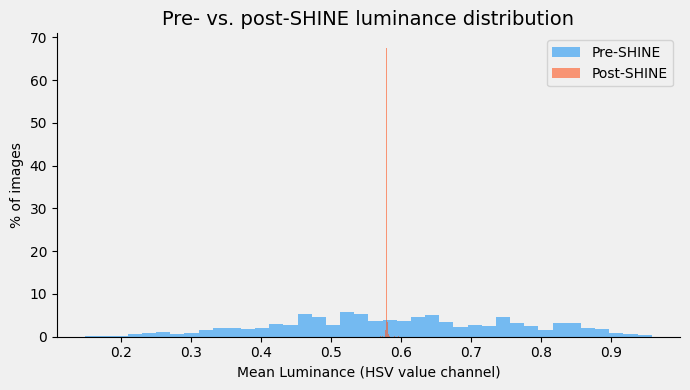

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
for stage, color, label in [
    ('pre_shine',  '#2196F3', 'Pre-SHINE'),
    ('post_shine', '#FF5722', 'Post-SHINE'),
]:
    vals = all_feats.loc[all_feats['stage'] == stage, 'mean_luminance'].values
    weights = np.full(len(vals), 100.0 / len(vals))
    ax.hist(vals, bins=40, alpha=0.6, color=color, label=label, weights=weights)

ax.set_xlabel('Mean Luminance (HSV value channel)')
ax.set_ylabel('% of images')
ax.set_title('Pre- vs. post-SHINE luminance distribution', fontsize=14)
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [7]:
# Summary table: mean +/- SD of mean luminance, per stage x category
def lum_summary(df_all, groupby_col):
    rows = []
    for stage in ("pre_shine", "post_shine"):
        sub = df_all[df_all["stage"] == stage]
        if groupby_col == "all":
            rows.append({"group": "all", "stage": stage,
                         "mean": sub["mean_luminance"].mean(),
                         "sd":   sub["mean_luminance"].std()})
        else:
            for grp, g in sub.groupby(groupby_col):
                rows.append({"group": grp, "stage": stage,
                             "mean": g["mean_luminance"].mean(),
                             "sd":   g["mean_luminance"].std()})
    pivoted = pd.DataFrame(rows).pivot(index="group", columns="stage", values=["mean", "sd"])
    # Explicitly reorder to pre -> post to avoid alphabetical column swap
    pivoted = pivoted.reindex(columns=pd.MultiIndex.from_tuples([
        ("mean", "pre_shine"), ("mean", "post_shine"),
        ("sd",   "pre_shine"), ("sd",   "post_shine"),
    ]))
    return pivoted

tbl_all = lum_summary(all_feats, "all")
tbl_l1  = lum_summary(all_feats, "L1")
tbl_l2  = lum_summary(all_feats, "L2")

summary_table = pd.concat([tbl_all, tbl_l1, tbl_l2])
summary_table.columns = ["Mean (pre)", "Mean (post)", "SD (pre)", "SD (post)"]
summary_table = summary_table.round(4)
print("Luminance summary (mean luminance of each image, averaged within group):")
display(summary_table)

Luminance summary (mean luminance of each image, averaged within group):


,Mean (pre),Mean (post),SD (pre),SD (post)
group,,,,
all,0.5924,0.5794,0.1685,0.0012
animate,0.5410,0.5792,0.1456,0.0007
inanimate,0.6283,0.5795,0.1741,0.0014
animal_body,0.5163,0.5793,0.1590,0.0004
animal_face,0.5399,0.5791,0.1216,0.0005
handmade_object,0.5974,0.5794,0.1698,0.0014
human_body,0.6429,0.5791,0.1625,0.0014
human_face,0.4992,0.5791,0.1008,0.0002
natural_object,0.6799,0.5797,0.1694,0.0013


## 4. Pairwise pixel correlation (post-SHINE, sub-sampled)

Computing pairwise correlations for 1000 pairs...
Pairwise pixel correlation (post-SHINE): mean=0.2678, SD=0.1647


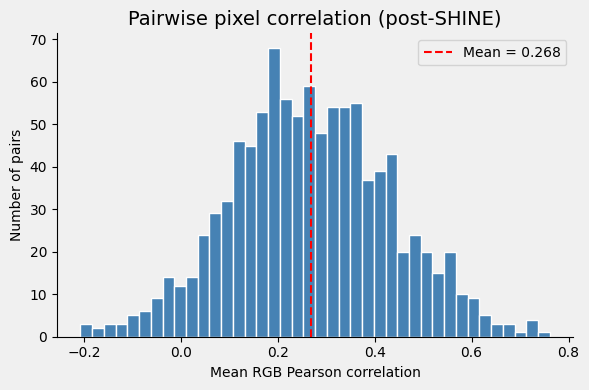

In [8]:
MAX_PAIRS = 1000   # sub-sample for tractability

post_paths = post_df['path'].tolist()
pair_indices = list(combinations(range(len(post_paths)), 2))
rng = np.random.default_rng(seed=42)
if len(pair_indices) > MAX_PAIRS:
    pair_indices = [pair_indices[i] for i in rng.choice(len(pair_indices), MAX_PAIRS, replace=False)]

print(f'Computing pairwise correlations for {len(pair_indices)} pairs...')
cors = []
for a_idx, b_idx in pair_indices:
    img_a, _ = load_image(post_paths[a_idx])
    img_b, _ = load_image(post_paths[b_idx])
    ch_cors = [
        float(np.corrcoef(img_a[:, :, c].ravel(), img_b[:, :, c].ravel())[0, 1])
        for c in range(3)
    ]
    cors.append(np.mean(ch_cors))

cors = np.array(cors)
print(f'Pairwise pixel correlation (post-SHINE): mean={cors.mean():.4f}, SD={cors.std():.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(cors, bins=40, color='steelblue', edgecolor='white')
ax.axvline(cors.mean(), color='red', linestyle='--', label=f'Mean = {cors.mean():.3f}')
ax.set_xlabel('Mean RGB Pearson correlation')
ax.set_ylabel('Number of pairs')
ax.set_title('Pairwise pixel correlation (post-SHINE)', fontsize=14)
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 5. Per-feature comparison -- L1 (animate vs. inanimate)

Independent-samples t-test for each feature.

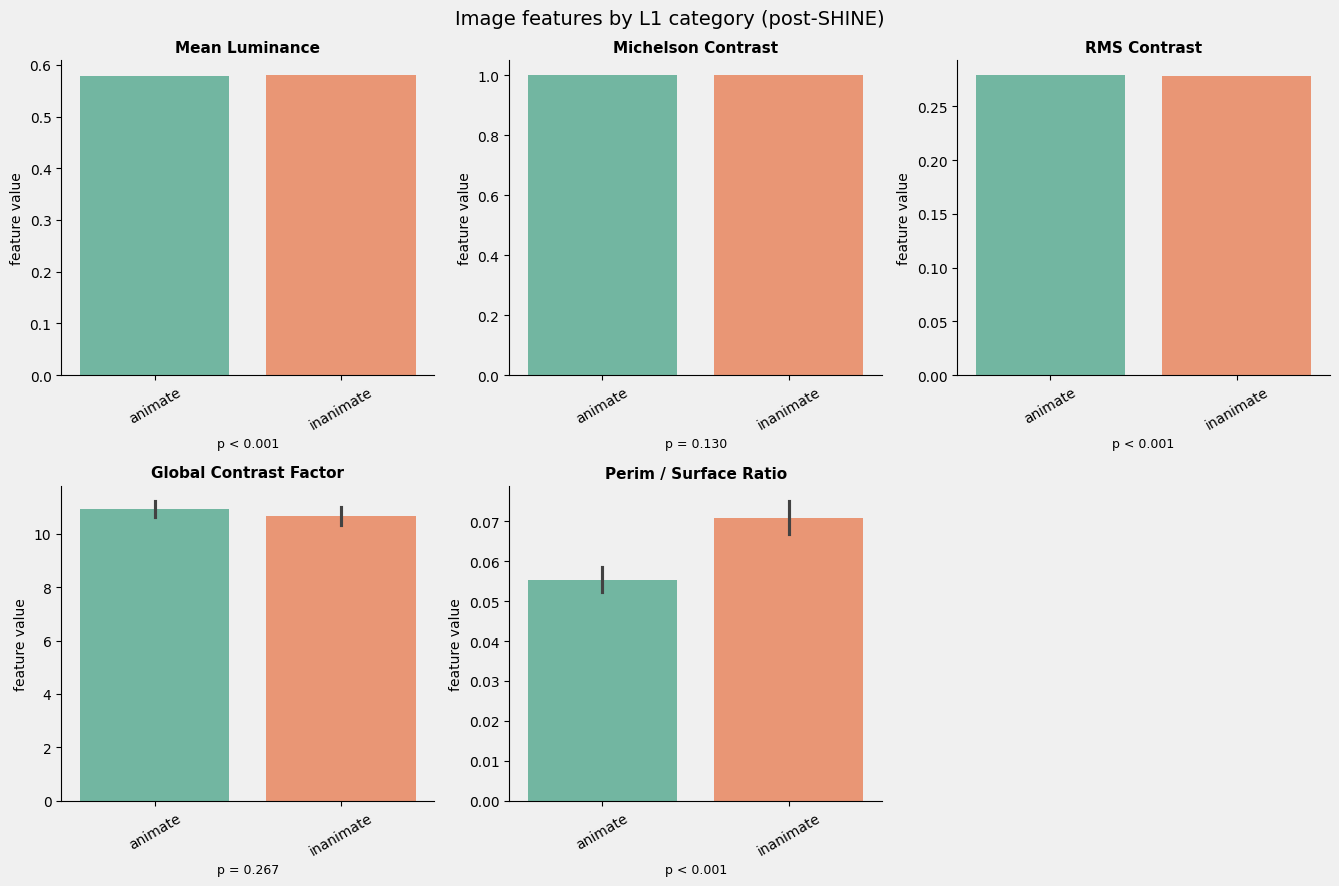

In [9]:
FEATURES = list(FEATURE_FUNCS.keys())
post_only = all_feats[all_feats['stage'] == 'post_shine'].copy()
l1_groups = sorted(post_only['L1'].unique())

fig, axes = plt.subplots(2, 3, figsize=(13.5, 9))
axes.flat[-1].set_visible(False)

for ax, feat in zip(axes.flat, FEATURES):
    sns.barplot(
        data=post_only, x='L1', y=feat,
        order=l1_groups,
        errorbar=('ci', 95),
        palette='Set2',
        ax=ax,
    )
    ax.set_title(FEATURE_LABELS[feat], fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('feature value')
    ax.tick_params(axis='x', rotation=30)

    if len(l1_groups) == 2:
        g1 = post_only.loc[post_only['L1'] == l1_groups[0], feat].dropna()
        g2 = post_only.loc[post_only['L1'] == l1_groups[1], feat].dropna()
        _, p_val = stats.ttest_ind(g1, g2)
        p_str = 'p = n/a' if np.isnan(p_val) else (f'p = {p_val:.3f}' if p_val >= 0.001 else 'p < 0.001')
        ax.set_xlabel(p_str, fontsize=9, color='black')

    sns.despine(ax=ax)

fig.suptitle('Image features by L1 category (post-SHINE)', fontsize=14)
plt.tight_layout()
plt.show()


## 6. Per-feature comparison -- L2 categories

One-way ANOVA + pairwise t-tests (Bonferroni corrected).

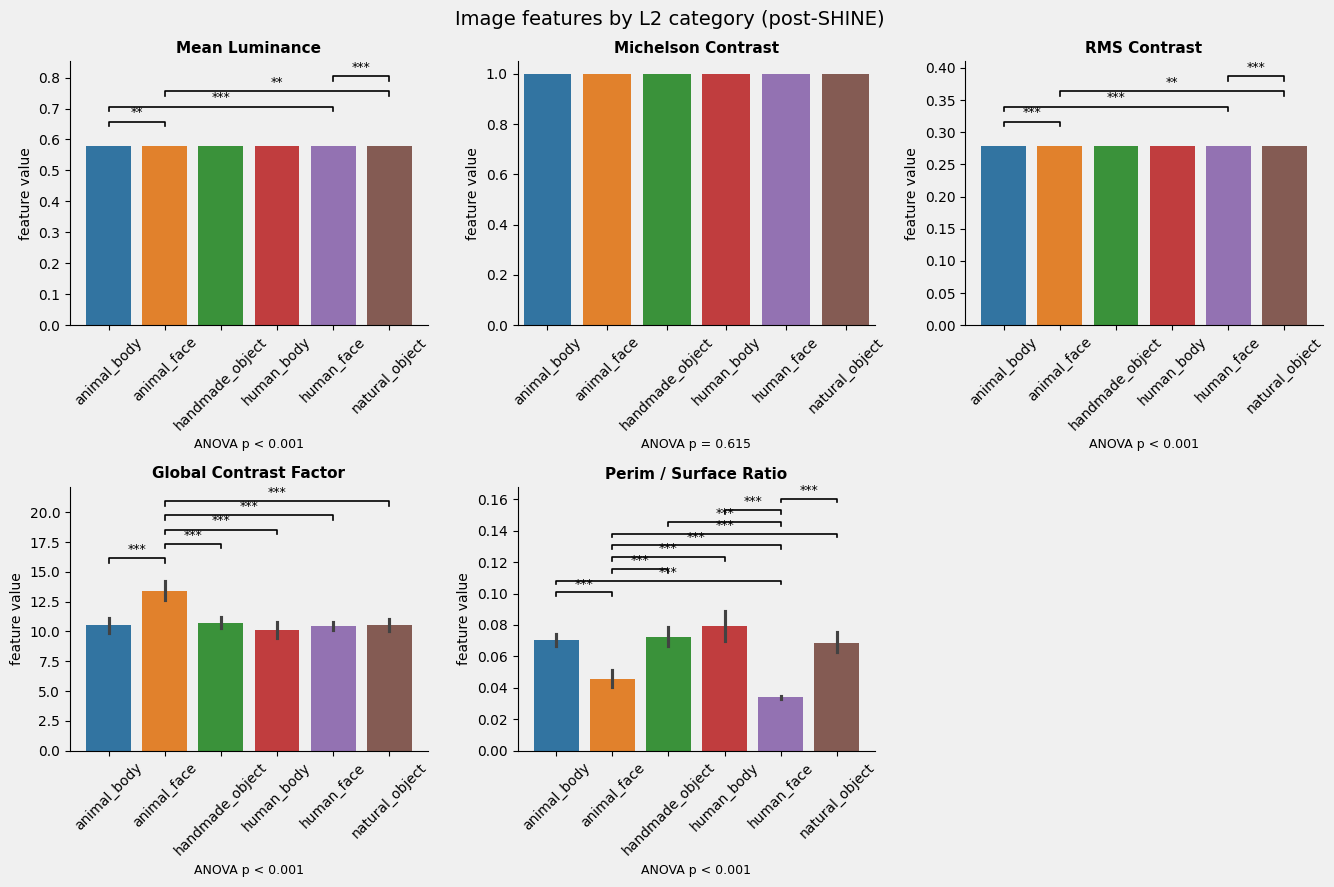

In [10]:
l2_groups = sorted(post_only['L2'].unique())
n_groups_l2 = len(l2_groups)

fig, axes = plt.subplots(2, 3, figsize=(13.5, 9))
axes.flat[-1].set_visible(False)

for ax, feat in zip(axes.flat, FEATURES):
    sns.barplot(
        data=post_only, x='L2', y=feat,
        order=l2_groups,
        errorbar=('ci', 95),
        palette='tab10',
        ax=ax,
    )
    ax.set_title(FEATURE_LABELS[feat], fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('feature value')
    ax.tick_params(axis='x', rotation=45)

    groups_data = [
        post_only.loc[post_only['L2'] == g, feat].dropna().values
        for g in l2_groups
    ]
    F, p_anova = stats.f_oneway(*groups_data)
    pairs = list(combinations(range(n_groups_l2), 2))
    alpha_bonf = 0.05 / len(pairs)
    sig_pairs = []
    for i, j in pairs:
        _, p_pair = stats.ttest_ind(groups_data[i], groups_data[j])
        if p_pair < alpha_bonf:
            sig_pairs.append((i, j, p_pair))

    p_str = 'ANOVA p = n/a' if np.isnan(p_anova) else (f'ANOVA p = {p_anova:.3f}' if p_anova >= 0.001 else 'ANOVA p < 0.001')
    ax.set_xlabel(p_str, fontsize=9, color='black')

    y_base  = ax.get_ylim()[1]
    y_range = y_base - ax.get_ylim()[0]
    step    = y_range * 0.08
    leg_h   = y_range * 0.025
    for k, (i, j, p_pair) in enumerate(sig_pairs):
        y_top = y_base + step * (k + 1)
        ax.plot([i, i, j, j], [y_top - leg_h, y_top, y_top, y_top - leg_h],
                lw=1.2, color='black', clip_on=False)
        sig_label = '***' if p_pair < 0.001 else ('**' if p_pair < 0.01 else '*')
        ax.text((i + j) / 2, y_top + leg_h * 0.5, sig_label,
                ha='center', va='bottom', fontsize=9, clip_on=False)
    if sig_pairs:
        ax.set_ylim(top=y_base + step * (len(sig_pairs) + 1))

    sns.despine(ax=ax)

fig.suptitle('Image features by L2 category (post-SHINE)', fontsize=14)
plt.tight_layout()
plt.show()


## 7. Did SHINE change categories differently?

For each image and feature, compute $\Delta = post - pre$. A significant difference in $\Delta$ across categories means SHINE was not category-neutral -- it equalized some groups more than others. This is equivalent to a stage×category interaction in a mixed ANOVA.

In [11]:
# Compute per-image delta (post - pre), matched on filename
pre_f  = all_feats[all_feats["stage"] == "pre_shine"].set_index("filename")[FEATURES + ["L1", "L2"]]
post_f = all_feats[all_feats["stage"] == "post_shine"].set_index("filename")[FEATURES + ["L1", "L2"]]

delta_df = (post_f[FEATURES] - pre_f[FEATURES]).copy()
delta_df["L1"] = post_f["L1"]
delta_df["L2"] = post_f["L2"]
delta_df = delta_df.reset_index()

print(f"Delta rows: {len(delta_df)}")
delta_df[FEATURES + ["L1", "L2"]].describe().round(4)

# perim_to_surface_ratio excluded from delta analysis:
# it depends only on the alpha mask, which SHINE should not modify.
# A non-zero delta indicates SHINE stripped the alpha channel in its output
# (pipeline issue in shine_equalize.m), not a genuine image-content change.
DELTA_FEATURES = [f for f in FEATURES if f != 'perim_to_surface_ratio']


Delta rows: 725


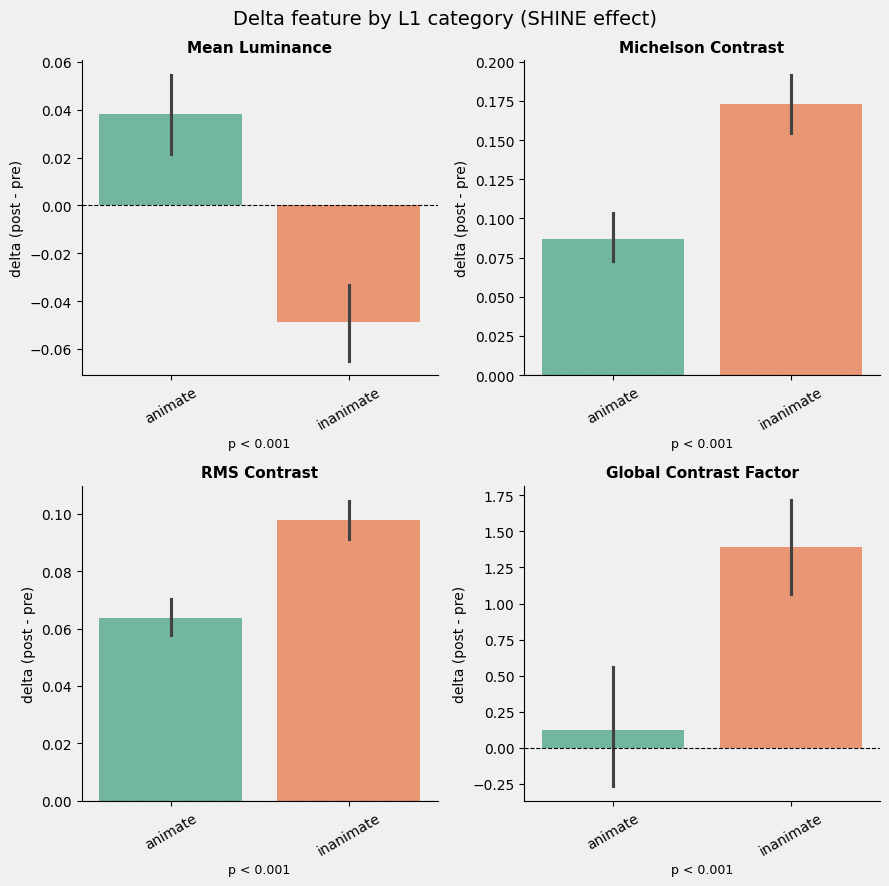

In [12]:
# L1: t-test on delta (animate vs. inanimate)
l1_groups_d = sorted(delta_df['L1'].unique())

fig, axes = plt.subplots(2, 2, figsize=(9, 9))

for ax, feat in zip(axes.flat, DELTA_FEATURES):
    sns.barplot(
        data=delta_df, x='L1', y=feat,
        order=l1_groups_d,
        errorbar=('ci', 95),
        palette='Set2',
        ax=ax,
    )
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(FEATURE_LABELS[feat], fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('delta (post - pre)')
    ax.tick_params(axis='x', rotation=30)

    if len(l1_groups_d) == 2:
        g1 = delta_df.loc[delta_df['L1'] == l1_groups_d[0], feat].dropna()
        g2 = delta_df.loc[delta_df['L1'] == l1_groups_d[1], feat].dropna()
        _, p_val = stats.ttest_ind(g1, g2)
        p_str = 'p = n/a' if np.isnan(p_val) else (f'p = {p_val:.3f}' if p_val >= 0.001 else 'p < 0.001')
        ax.set_xlabel(p_str, fontsize=9, color='black')

    sns.despine(ax=ax)

fig.suptitle('Delta feature by L1 category (SHINE effect)', fontsize=14)
plt.tight_layout()
plt.show()


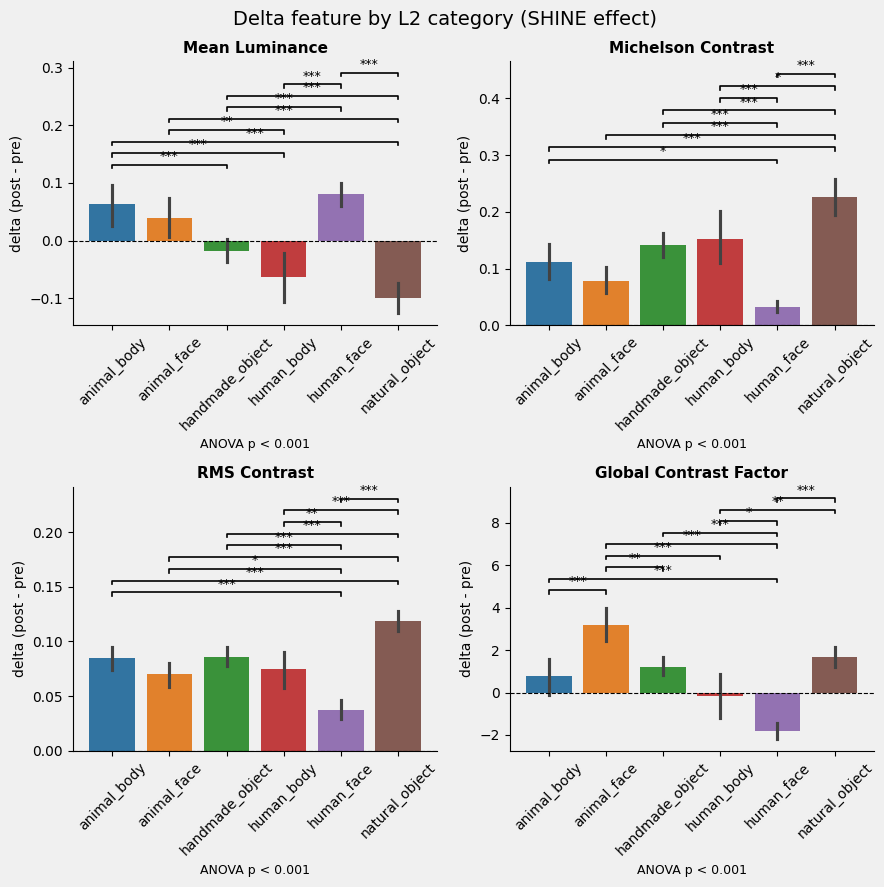

In [13]:
# L2: one-way ANOVA + Tukey HSD on delta
from scipy.stats import tukey_hsd

l2_groups_d = sorted(delta_df['L2'].unique())
n_groups_l2 = len(l2_groups_d)

fig, axes = plt.subplots(2, 2, figsize=(9, 9))

for ax, feat in zip(axes.flat, DELTA_FEATURES):
    sns.barplot(
        data=delta_df, x='L2', y=feat,
        order=l2_groups_d,
        errorbar=('ci', 95),
        palette='tab10',
        ax=ax,
    )
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(FEATURE_LABELS[feat], fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('delta (post - pre)')
    ax.tick_params(axis='x', rotation=45)

    groups_data = [
        delta_df.loc[delta_df['L2'] == g, feat].dropna().values
        for g in l2_groups_d
    ]
    F, p_anova = stats.f_oneway(*groups_data)
    tukey = tukey_hsd(*groups_data)
    sig_pairs = [
        (i, j, tukey.pvalue[i, j])
        for i, j in combinations(range(n_groups_l2), 2)
        if tukey.pvalue[i, j] < 0.05
    ]

    p_str = 'ANOVA p = n/a' if np.isnan(p_anova) else (f'ANOVA p = {p_anova:.3f}' if p_anova >= 0.001 else 'ANOVA p < 0.001')
    ax.set_xlabel(p_str, fontsize=9, color='black')

    y_base  = ax.get_ylim()[1]
    y_range = y_base - ax.get_ylim()[0]
    step    = y_range * 0.08
    leg_h   = y_range * 0.025
    for k, (i, j, p_pair) in enumerate(sig_pairs):
        y_top = y_base + step * (k + 1)
        ax.plot([i, i, j, j], [y_top - leg_h, y_top, y_top, y_top - leg_h],
                lw=1.2, color='black', clip_on=False)
        sig_label = '***' if p_pair < 0.001 else ('**' if p_pair < 0.01 else '*')
        ax.text((i + j) / 2, y_top + leg_h * 0.5, sig_label,
                ha='center', va='bottom', fontsize=9, clip_on=False)
    if sig_pairs:
        ax.set_ylim(top=y_base + step * (len(sig_pairs) + 1))

    sns.despine(ax=ax)

fig.suptitle('Delta feature by L2 category (SHINE effect)', fontsize=14)
plt.tight_layout()
plt.show()
